In [5]:
import pandas as pd
df1=pd.read_csv("train.csv")
df2=pd.read_csv("public_test.csv")
df=pd.concat([df1,df2])

In [6]:
df.isna().sum()

,0
User_ID,0
Age,1952
Income,1285
City_Tier,0
Device_Type,0
Traffic_Source,0
Pages_Viewed,0
Products_Viewed,0
Time_On_Site,2416
Previous_Purchases,0


In [7]:
df.describe()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
count,13000.000000,11048.000000,11715.000000,13000.000000,13000.000000,13000.000000,10584.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000
mean,27269.730769,41.504254,70224.788193,1.934769,15.555385,15.175154,13.693348,2.987154,0.542923,12.511385,5509.580769,0.305615
std,40740.313429,13.829850,24720.755122,0.741788,8.643409,8.955017,19.876401,1.735376,0.498173,6.911585,2590.339395,0.460685
min,1.000000,18.000000,12000.000000,1.000000,1.000000,1.000000,0.590000,0.000000,0.000000,1.000000,1000.000000,0.000000
25%,3250.750000,29.000000,52755.197864,1.000000,8.000000,8.000000,7.637500,2.000000,0.000000,7.000000,3261.750000,0.000000
50%,6500.500000,42.000000,70367.603579,2.000000,16.000000,15.000000,11.140000,3.000000,1.000000,12.000000,5511.000000,0.000000
75%,9750.250000,53.000000,87187.605567,2.000000,23.000000,23.000000,15.660000,4.000000,1.000000,19.000000,7746.250000,1.000000
max,103000.000000,65.000000,161687.774167,3.000000,30.000000,37.000000,607.390000,12.000000,1.000000,24.000000,9998.000000,1.000000


In [8]:
df

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,1,58.0,103593.708812,2,Mobile,Organic,5,4,9.61,3,0,11,2418,0
1,2,26.0,36451.716984,2,Mobile,Social Media,11,3,17.63,2,0,14,1213,0
2,3,19.0,30511.228700,3,Mobile,Referral,1,1,13.25,5,0,5,2849,0
3,4,48.0,87789.172342,3,Mobile,Email,14,12,NaN,1,1,19,7610,0
4,5,35.0,105229.249067,2,Mobile,Social Media,14,21,16.92,1,0,5,9261,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,102996,44.0,67120.188908,2,Desktop,Organic,9,15,13.88,3,1,5,5987,1
2996,102997,NaN,101304.417703,3,Desktop,Organic,1,4,7.63,4,1,16,4807,0
2997,102998,49.0,NaN,1,Tablet,Social Media,15,13,11.42,2,0,8,8419,0
2998,102999,43.0,82385.919156,3,Tablet,Email,8,5,NaN,3,1,8,3138,0


## Features Engineering & Data Handling

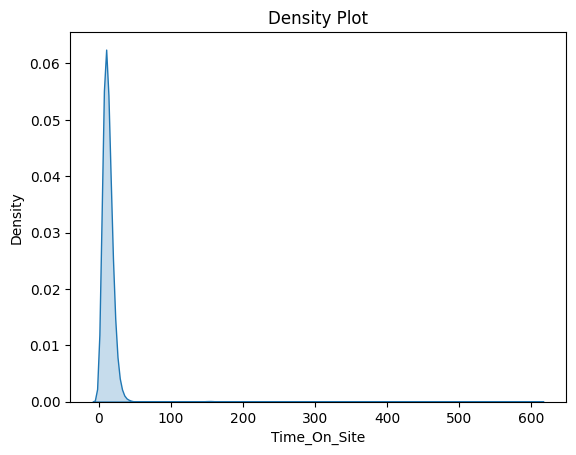

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df['Time_On_Site'], fill=True)
plt.title('Density Plot')
plt.show()

### Checking if Outliers are there or not

<Axes: ylabel='Time_On_Site'>

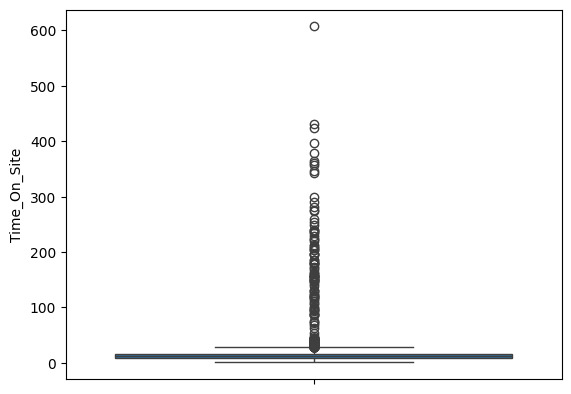

In [10]:
import seaborn as sns
sns.boxplot(df["Time_On_Site"])

<Axes: ylabel='Age'>

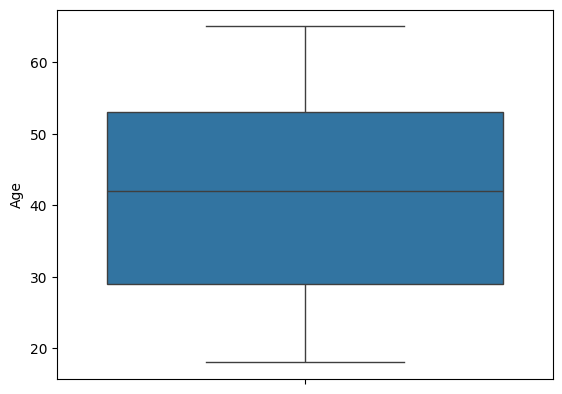

In [11]:
import seaborn as sns
sns.boxplot(df["Age"])

### NEW FEATURE CREATION

## Time_On_site was right_sckewed, oultier removal using log distribution

In [12]:
import numpy as np
df['Time_On_Site_log'] = np.log1p(df['Time_On_Site'])

In [13]:
df['Time_On_Site_log'].fillna(df['Time_On_Site_log'].median(), inplace=True)

/tmp/ipykernel_1889/3133040830.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time_On_Site_log'].fillna(df['Time_On_Site_log'].median(), inplace=True)


In [14]:
time_log=df['Time_On_Site_log'].median()
time=df["Time_On_Site"].median()

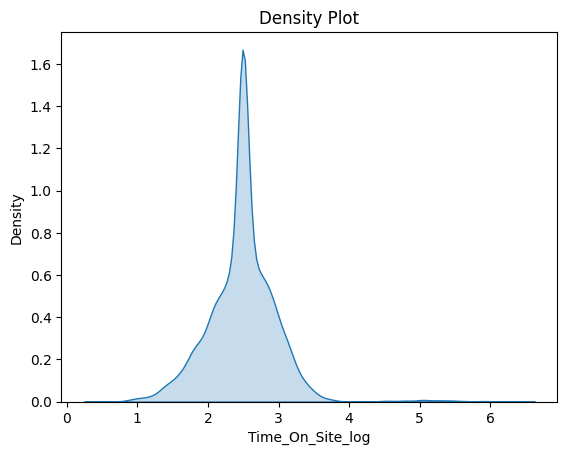

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df['Time_On_Site_log'], fill=True)
plt.title('Density Plot')
plt.show()

<Axes: ylabel='Income'>

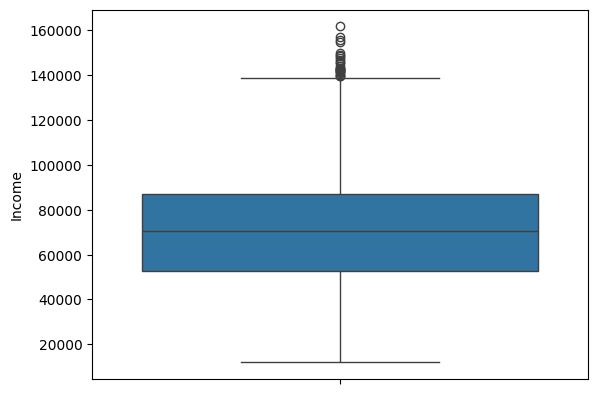

In [16]:
import seaborn as sns
sns.boxplot(df["Income"])

In [17]:
df["Income"].fillna(df["Income"].median(), inplace=True)
df["Age"].fillna(df["Age"].mean(), inplace=True)
df["Time_On_Site"].fillna(df["Time_On_Site"].median(), inplace=True)


/tmp/ipykernel_1889/855305464.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(df["Income"].median(), inplace=True)
/tmp/ipykernel_1889/855305464.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [18]:
df.describe()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted,Time_On_Site_log
count,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000
mean,27269.730769,41.504254,70238.904945,1.934769,15.555385,15.175154,13.218818,2.987154,0.542923,12.511385,5509.580769,0.305615,2.489041
std,40740.313429,12.749251,23467.135826,0.741788,8.643409,8.955017,17.961896,1.735376,0.498173,6.911585,2590.339395,0.460685,0.489008
min,1.000000,18.000000,12000.000000,1.000000,1.000000,1.000000,0.590000,0.000000,0.000000,1.000000,1000.000000,0.000000,0.463734
25%,3250.750000,32.000000,55003.502501,1.000000,8.000000,8.000000,8.460000,2.000000,0.000000,7.000000,3261.750000,0.000000,2.247072
50%,6500.500000,41.504254,70367.603579,2.000000,16.000000,15.000000,11.140000,3.000000,1.000000,12.000000,5511.000000,0.000000,2.496506
75%,9750.250000,51.000000,85162.614835,2.000000,23.000000,23.000000,14.390000,4.000000,1.000000,19.000000,7746.250000,1.000000,2.733718
max,103000.000000,65.000000,161687.774167,3.000000,30.000000,37.000000,607.390000,12.000000,1.000000,24.000000,9998.000000,1.000000,6.410816


In [19]:
df[(df["Age"] > 17) & (df["Age"] < 35)].shape

(3908, 15)

In [20]:
df[(df["Age"] > 17) & (df["Age"] < 35)].describe()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted,Time_On_Site_log
count,3908.000000,3908.000000,3908.000000,3908.000000,3908.000000,3908.000000,3908.000000,3908.000000,3908.000000,3908.000000,3908.000000,3908.000000,3908.000000
mean,26913.912999,26.016888,70134.986977,1.924002,15.736694,15.381013,13.158874,2.986694,0.540430,12.621801,5533.900716,0.309621,2.487213
std,40535.741968,4.896651,23274.495886,0.738781,8.722876,8.972353,18.710567,1.752055,0.498427,6.842875,2596.100608,0.462397,0.484689
min,2.000000,18.000000,12000.000000,1.000000,1.000000,1.000000,0.840000,0.000000,0.000000,1.000000,1000.000000,0.000000,0.609766
25%,3267.750000,22.000000,54778.817137,1.000000,8.000000,8.000000,8.467500,2.000000,0.000000,7.000000,3302.750000,0.000000,2.247865
50%,6362.500000,26.000000,70367.603579,2.000000,16.000000,15.000000,11.140000,3.000000,1.000000,12.000000,5561.500000,0.000000,2.496506
75%,9672.250000,30.000000,85147.711318,2.000000,23.000000,23.000000,14.340000,4.000000,1.000000,19.000000,7745.250000,1.000000,2.730464
max,102993.000000,34.000000,142614.496775,3.000000,30.000000,37.000000,607.390000,10.000000,1.000000,24.000000,9998.000000,1.000000,6.410816


In [21]:
df[(df["Age"] > 35) & (df["Age"] <60 )].shape

(7491, 15)

In [22]:
df[(df["Age"] > 35) & (df["Age"] <60 )].describe()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted,Time_On_Site_log
count,7491.000000,7491.000000,7491.000000,7491.000000,7491.000000,7491.000000,7491.000000,7491.000000,7491.000000,7491.000000,7491.000000,7491.000000,7491.000000
mean,27351.116807,45.966000,70171.102163,1.940862,15.442264,15.041650,13.204957,2.987986,0.546389,12.445601,5485.120945,0.303698,2.487563
std,40762.602051,6.500936,23553.078307,0.746402,8.587333,8.887736,17.709484,1.723896,0.497877,6.951142,2579.981476,0.459884,0.489733
min,1.000000,36.000000,12000.000000,1.000000,1.000000,1.000000,0.590000,0.000000,0.000000,1.000000,1002.000000,0.000000,0.463734
25%,3273.500000,41.504254,54901.115593,1.000000,8.000000,7.000000,8.430000,2.000000,0.000000,6.000000,3246.000000,0.000000,2.243896
50%,6601.000000,43.000000,70367.603579,2.000000,15.000000,15.000000,11.140000,3.000000,1.000000,12.000000,5488.000000,0.000000,2.496506
75%,9750.000000,51.000000,85166.920538,3.000000,23.000000,22.000000,14.375000,4.000000,1.000000,19.000000,7718.500000,1.000000,2.732743
max,103000.000000,59.000000,161687.774167,3.000000,30.000000,37.000000,431.100000,12.000000,1.000000,24.000000,9997.000000,1.000000,6.068657


## Mostly every features remains same for age group, so better divide them on basis of group, make a categorical feature.

In [23]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 25, 35, 50, 100],
    labels=["Teen", "Young", "Adult", "Mid", "Senior"]
)

In [24]:
pd.crosstab(
    df['Previous_Purchases'],
    df['Converted'],
    normalize="index"
)*100

Converted,0,1
Previous_Purchases,,
0,75.627770,24.372230
1,74.294355,25.705645
2,73.538677,26.461323
3,69.212163,30.787837
4,67.374605,32.625395
5,62.211982,37.788018
6,61.682243,38.317757
7,57.352941,42.647059
8,51.754386,48.245614


### NEW FEATURE CREATION

In [25]:
df["Previous_Buyer"] = (
    (df["Previous_Purchases"] > 0) |
    (df["Discount_Seen"] > 0)
).astype(int)

In [26]:
pd.crosstab(
    df['Previous_Buyer'],
    df['Converted'],
    normalize="index"
)*100

Converted,0,1
Previous_Buyer,,
0,82.666667,17.333333
1,69.125984,30.874016


In [27]:
df["Previous_Buyer"].corr(df["Converted"])

np.float64(0.04413387252557618)

In [28]:
pd.crosstab(
    df['Traffic_Source'],
    df['Converted']
)

Converted,0,1
Traffic_Source,,
Email,778,429
Organic,2830,1155
Paid Ads,2421,904
Referral,1190,709
Social Media,1808,776


In [29]:
pd.crosstab(
    df['City_Tier'],
    df['Converted']
)

Converted,0,1
City_Tier,,
1,2801,1227
2,3969,1823
3,2257,923


In [30]:
pd.crosstab(
    df['Products_Viewed'],
    df['Converted'],
    normalize='index'
) * 100

Converted,0,1
Products_Viewed,,
1,89.014723,10.985277
2,89.341693,10.658307
3,89.665653,10.334347
4,85.784314,14.215686
5,87.531807,12.468193
6,83.027523,16.972477
7,85.557987,14.442013
8,82.391304,17.608696
9,81.208054,18.791946


In [31]:
pd.crosstab(
    df['Browser_Version'],
    df['Converted'],
    normalize='index'
)*100

Converted,0,1
Browser_Version,,
1,68.712871,31.287129
2,71.126761,28.873239
3,70.864662,29.135338
4,69.087838,30.912162
5,68.710359,31.289641
6,63.539823,36.460177
7,69.444444,30.555556
8,72.140221,27.859779
9,69.333333,30.666667


In [32]:
temp = (
    df.groupby(["Device_Type","Browser_Version"])["Converted"]
      .agg(["count","mean"])
      .reset_index()
)

temp[temp["count"] >= 30].sort_values("mean", ascending=False)

,Device_Type,Browser_Version,count,mean
51,Tablet,4,60,0.450000
22,Desktop,23,126,0.412698
11,Desktop,12,159,0.396226
3,Desktop,4,156,0.391026
5,Desktop,6,147,0.374150
...,...,...,...,...
50,Tablet,3,57,0.245614
62,Tablet,15,37,0.243243
63,Tablet,16,51,0.235294
54,Tablet,7,60,0.200000


In [33]:
df[["Browser_Version",
    "Products_Viewed",
    "Pages_Viewed",
    "Converted",
    "Previous_Purchases","Time_On_Site"]].corr()

,Browser_Version,Products_Viewed,Pages_Viewed,Converted,Previous_Purchases,Time_On_Site
Browser_Version,1.000000,-0.006820,-0.003445,-0.003448,-0.002050,-0.014897
Products_Viewed,-0.006820,1.000000,0.945739,0.306044,-0.000598,0.010807
Pages_Viewed,-0.003445,0.945739,1.000000,0.308487,-0.005489,0.007291
Converted,-0.003448,0.306044,0.308487,1.000000,0.104794,0.085518
Previous_Purchases,-0.002050,-0.000598,-0.005489,0.104794,1.000000,0.000214
Time_On_Site,-0.014897,0.010807,0.007291,0.085518,0.000214,1.000000


### NEW FEATURES CREATION

In [34]:
df["Engagement"] = (
    df["Products_Viewed"] +

    df["Time_On_Site_log"]
)
df["Product_per_Minute"] = df["Products_Viewed"] / (df["Time_On_Site_log"]+1)
df["Purchase_Rate"] = (
    df["Previous_Purchases"] /
    (df["Products_Viewed"] + 1)
)
df["Referral_Discount"] = (
    (df["Traffic_Source"] == "Referral").astype(int)
    * df["Discount_Seen"]
)

In [35]:
len(df["Campaign_Code"].unique())

6873

### ONE HOT ENCODING

In [36]:
df = pd.get_dummies(
    df,
    columns=["Traffic_Source","Age_Group","Device_Type"],
    dtype=int,
    drop_first=True
)

### DROP UNNECESSARY COLUMNS

In [37]:
df.drop(columns=["Pages_Viewed","User_ID","Age","Time_On_Site"], inplace=True)

In [38]:
df

,Income,City_Tier,Products_Viewed,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted,Time_On_Site_log,Previous_Buyer,...,Traffic_Source_Organic,Traffic_Source_Paid Ads,Traffic_Source_Referral,Traffic_Source_Social Media,Age_Group_Young,Age_Group_Adult,Age_Group_Mid,Age_Group_Senior,Device_Type_Mobile,Device_Type_Tablet
0,103593.708812,2,4,3,0,11,2418,0,2.361797,1,...,1,0,0,0,0,0,0,1,1,0
1,36451.716984,2,3,2,0,14,1213,0,2.924773,1,...,0,0,0,1,0,1,0,0,1,0
2,30511.228700,3,1,5,0,5,2849,0,2.656757,1,...,0,0,1,0,1,0,0,0,1,0
3,87789.172342,3,12,1,1,19,7610,0,2.496506,1,...,0,0,0,0,0,0,1,0,1,0
4,105229.249067,2,21,1,0,5,9261,0,2.885917,1,...,0,0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,67120.188908,2,15,3,1,5,5987,1,2.700018,1,...,1,0,0,0,0,0,1,0,0,0
2996,101304.417703,3,4,4,1,16,4807,0,2.155245,1,...,1,0,0,0,0,0,1,0,0,0
2997,70367.603579,1,13,2,0,8,8419,0,2.519308,1,...,0,0,0,1,0,0,1,0,0,1
2998,82385.919156,3,5,3,1,8,3138,0,2.496506,1,...,0,0,0,0,0,0,1,0,0,1


### CATEGORICAL COLUMNS

In [39]:
col_mode=[]
for col in df.columns:
    if df[col].nunique() < 9:
        col_mode.append(col)
col_mode.remove("Converted")
col_mode

['City_Tier',
 'Discount_Seen',
 'Previous_Buyer',
 'Referral_Discount',
 'Traffic_Source_Organic',
 'Traffic_Source_Paid Ads',
 'Traffic_Source_Referral',
 'Traffic_Source_Social Media',
 'Age_Group_Young',
 'Age_Group_Adult',
 'Age_Group_Mid',
 'Age_Group_Senior',
 'Device_Type_Mobile',
 'Device_Type_Tablet']

### TRAIN_TEST_SPLIT

In [40]:
X = df.drop(columns=["Converted"])
y = df["Converted"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## STANDRDISATION

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.drop(columns=col_mode))
X_test_scaled = scaler.transform(X_test.drop(columns=col_mode))

In [42]:
X_train

,Income,City_Tier,Products_Viewed,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Time_On_Site_log,Previous_Buyer,Engagement,...,Traffic_Source_Organic,Traffic_Source_Paid Ads,Traffic_Source_Referral,Traffic_Source_Social Media,Age_Group_Young,Age_Group_Adult,Age_Group_Mid,Age_Group_Senior,Device_Type_Mobile,Device_Type_Tablet
970,114179.156844,2,19,3,0,3,5088,3.303952,1,22.303952,...,1,0,0,0,0,0,1,0,1,0
2991,49283.108547,2,1,1,0,4,9510,2.417698,1,3.417698,...,0,0,1,0,1,0,0,0,1,0
563,70367.603579,2,13,3,1,13,6437,2.619583,1,15.619583,...,1,0,0,0,0,1,0,0,1,0
1905,89072.617981,2,13,4,1,22,2278,1.961502,1,14.961502,...,1,0,0,0,0,1,0,0,1,0
5778,46291.030881,3,20,3,0,7,8902,1.519513,1,21.519513,...,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,36355.155015,1,20,3,1,24,2157,3.161670,1,23.161670,...,0,0,0,1,0,0,0,1,1,0
5191,75608.035018,3,25,3,1,24,4364,3.099191,1,28.099191,...,0,0,0,1,0,0,0,1,1,0
5390,106271.466934,1,6,2,0,20,7653,2.520917,1,8.520917,...,1,0,0,0,0,0,0,1,0,0
860,42910.677668,2,14,2,1,2,3135,1.927164,1,15.927164,...,1,0,0,0,0,0,1,0,1,0


In [43]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.drop(columns=col_mode).columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.drop(columns=col_mode).columns,
    index=X_test.index
)

X_train = pd.concat(
    [X_train_scaled, X_train[col_mode]],
    axis=1
)

X_test = pd.concat(
    [X_test_scaled, X_test[col_mode]],
    axis=1
)

In [44]:
X_train.shape

(10400, 23)

### MODEL TRAINING

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
lr = LogisticRegression(max_iter=1000)
dt=DecisionTreeClassifier()
knn=KNeighborsClassifier()

### RANDOM FOREST VS LOGISTICS VS XGB VS KNN VS DT

In [46]:
from sklearn.metrics import f1_score

models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "Logistic Regression": lr,
    "KNN": knn,
    "Decision Tree": dt

}

best_model = None
best_f1 = 0

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)  # binary classification

    print(f"{name}: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

print(f"\nBest Model: {best_model_name}")
print(f"Best F1 Score: {best_f1:.4f}")

Random Forest: 0.3910
XGBoost: 0.4133
Logistic Regression: 0.3947
KNN: 0.3677
Decision Tree: 0.3913

Best Model: XGBoost
Best F1 Score: 0.4133


In [47]:
print(y_train.value_counts(normalize=True))

Converted
0    0.692885
1    0.307115
Name: proportion, dtype: float64


In [48]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1309  512]
 [ 465  314]]


### Hypertuning For XGB

In [49]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best Params:", search.best_params_)
print("Best F1:", search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.8}
Best F1: 0.3925660889516016


In [50]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=250,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.01,
    scale_pos_weight=2.24,
    colsample_bytree= 1,
    subsample= 0.8,
    gamma= 0,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

f1 = f1_score(y_test, y_pred)  # binary classification

print(f"{name}: {f1:.4f}")

Decision Tree: 0.5558


In [51]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    min_child_weight=3,
    max_depth=7,
    learning_rate=0.01,
    scale_pos_weight=2.24,
    colsample_bytree= 1,
    subsample= 0.8,
    gamma= 0,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

f1 = f1_score(y_test, y_pred)  # binary classification

print(f"{name}: {f1:.4f}")

Decision Tree: 0.5506


Features Importance in predicting

In [52]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                        Feature  Importance
6                    Engagement    0.137612
12            Referral_Discount    0.073710
10                Discount_Seen    0.069901
15      Traffic_Source_Referral    0.055826
1               Products_Viewed    0.044416
11               Previous_Buyer    0.042728
2            Previous_Purchases    0.040819
5              Time_On_Site_log    0.039110
22           Device_Type_Tablet    0.037748
17              Age_Group_Young    0.037215
8                 Purchase_Rate    0.036572
0                        Income    0.034919
14      Traffic_Source_Paid Ads    0.034855
7            Product_per_Minute    0.034158
16  Traffic_Source_Social Media    0.033011


### THRESHOLD TUNING FOR XGB

Best Threshold: 0.45999999999999985
Best F1: 0.5595296423321902


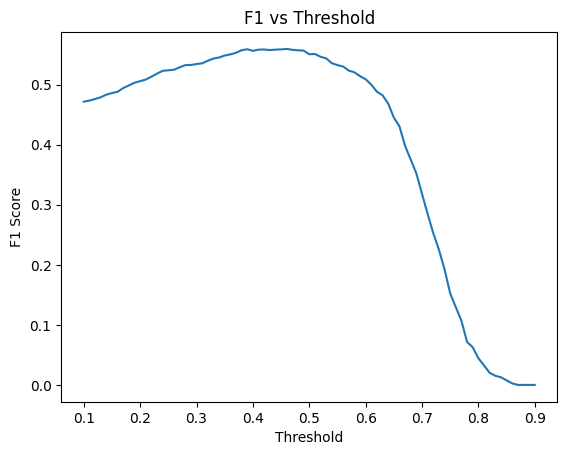

In [53]:
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.1, 0.91, 0.01)
y_prob = xgb.predict_proba(X_test)[:, 1]
f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_idx = np.argmax(f1_scores)

print("Best Threshold:", thresholds[best_idx])
print("Best F1:", f1_scores[best_idx])

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold")
plt.show()

In [54]:

threshold = .46


y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)
f1 = f1_score(y_test, y_pred)  # binary classification
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"{name}: {f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6542307692307693
Decision Tree: 0.5595

Confusion Matrix:
[[1130  691]
 [ 208  571]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

## Logistics Regression Implementation

### First Checking

In [56]:
# Model
model = LogisticRegression(max_iter=1000,class_weight='balanced')

# Training
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
f1 = f1_score(y_test, y_pred)
print(f"{name}: {f1:.4f}")

Accuracy: 0.6746153846153846

Confusion Matrix:
[[1206  615]
 [ 231  548]]
Decision Tree: 0.5644


## Threshold Tuning for LR

Best Threshold: 0.4999999999999998
Best F1: 0.564366632337796


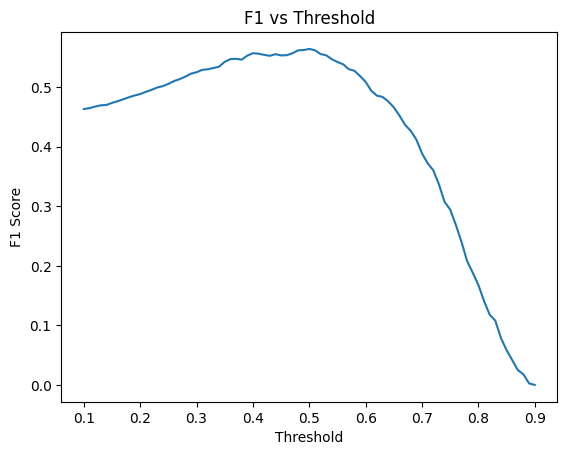

In [57]:
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.1, 0.91, 0.01)
y_prob = model.predict_proba(X_test)[:, 1]
f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_idx = np.argmax(f1_scores)

print("Best Threshold:", thresholds[best_idx])
print("Best F1:", f1_scores[best_idx])

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold")
plt.show()

In [58]:
threshold = .5

y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)
f1 = f1_score(y_test, y_pred)  # binary classification
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"{name}: {f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6703846153846154
Decision Tree: 0.5506

Confusion Matrix:
[[1218  603]
 [ 254  525]]


## LightBoost Implementation

In [ ]:
pip install lightgbm

### First Checking

In [59]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# X = features
# y = target


# Create LightGBM classifier
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    scale_pos_weight=2.42,
    random_state=42

)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3194, number of negative: 7206
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002603 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 10400, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.307115 -> initscore=-0.813640
[LightGBM] [Info] Start training from score -0.813640
Accuracy: 0.6711538461538461
F1 Score: 0.5335515548281505
Confusion Matrix:
 [[1256  565]
 [ 290  489]]


## Hypertuning for LGB

In [60]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
from sklearn.metrics import f1_score, make_scorer

lgb_model = lgb.LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

param_dist = {
    'n_estimators': [200, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [20, 31, 50, 80],
    'max_depth': [-1, 5, 10, 15],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

scorer = make_scorer(f1_score)

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best F1:", random_search.best_score_)

best_model = random_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3194, number of negative: 7206
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002274 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 10400, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [70]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# X = features
# y = target


# Create LightGBM classifier
model = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.01,
    num_leaves=50,
    max_depth=5,
    scale_pos_weight=2.42,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42

)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3194, number of negative: 7206
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 10400, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.307115 -> initscore=-0.813640
[LightGBM] [Info] Start training from score -0.813640
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [73]:
import joblib
import pickle
joblib.dump(model, "lgb.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
joblib.dump(col_mode, "col_mode.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Threshold Tuning for LGB

Best Threshold: 0.47999999999999976
Best F1: 0.564200477326969


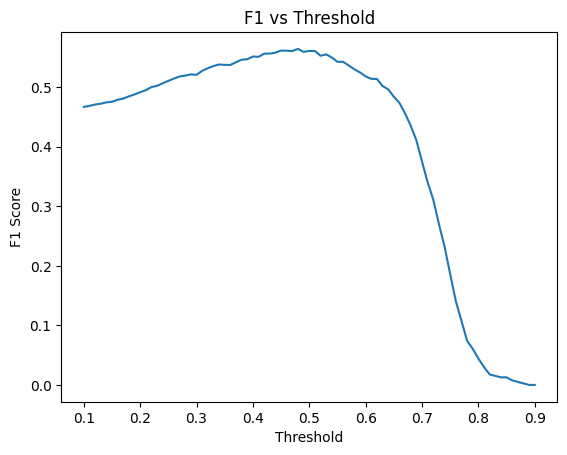

In [63]:
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
y_prob = model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.91, 0.01)
y_pred = (y_prob >= threshold).astype(int)
f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_idx = np.argmax(f1_scores)

print("Best Threshold:", thresholds[best_idx])
print("Best F1:", f1_scores[best_idx])

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold")
plt.show()

In [65]:

threshold = .48
 # binary classification

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)
f1 = f1_score(y_test, y_pred)  # binary classification
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"{name}: {f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6488461538461539
Decision Tree: 0.5642

Confusion Matrix:
[[1096  725]
 [ 188  591]]


In [74]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.62      0.72      1821
           1       0.46      0.74      0.56       779

    accuracy                           0.66      2600
   macro avg       0.65      0.68      0.64      2600
weighted avg       0.73      0.66      0.67      2600



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


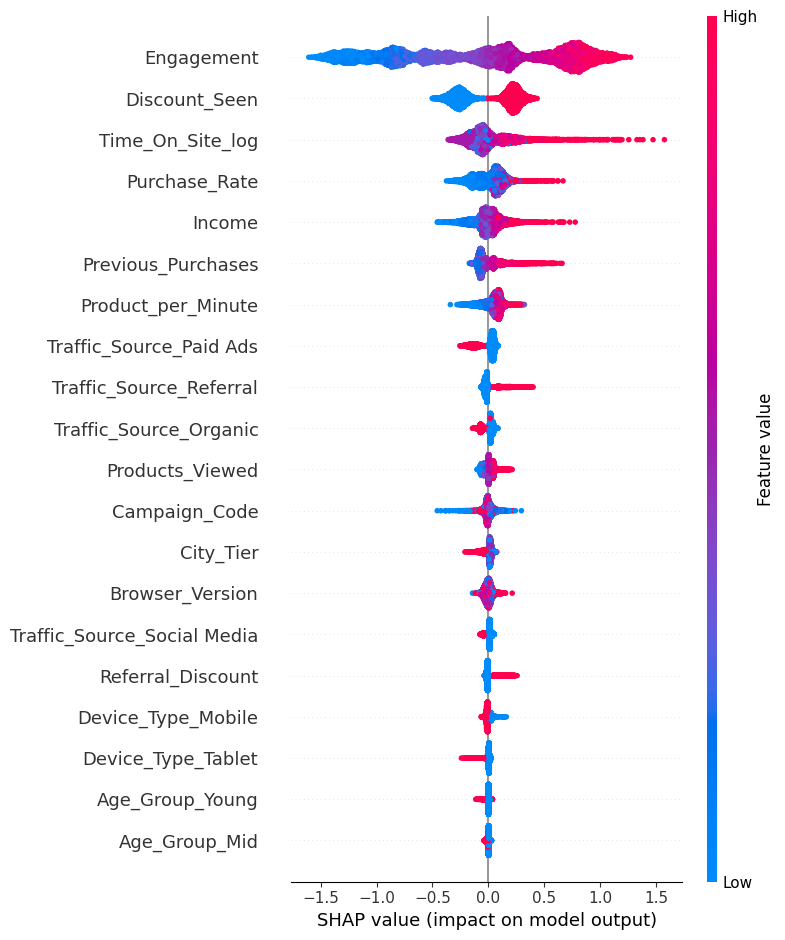

In [68]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

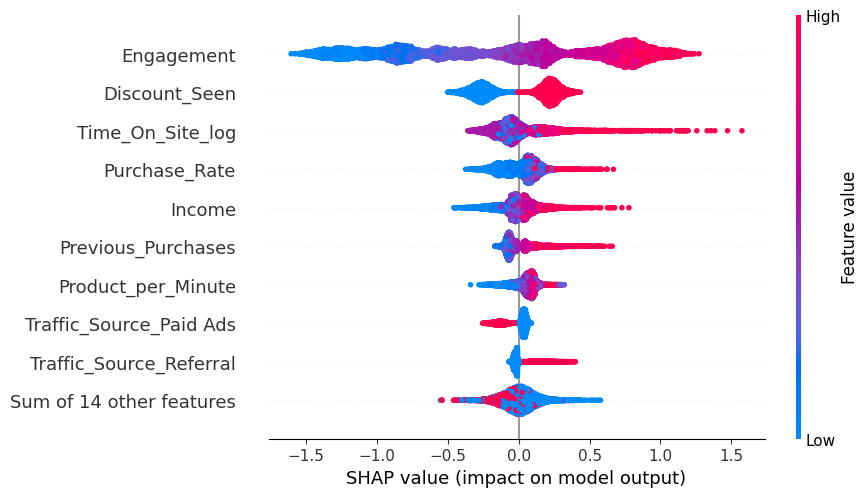

In [69]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

shap.plots.beeswarm(shap_values)

### Both XGBoost LightGBM and Logistics Regression produced comparable results, indicating model performance was primarily constrained by the available features rather than the choice of boosting algorithm.

In [75]:
import joblib

model = joblib.load("lgb.pkl")
scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")
col_mode = joblib.load("col_mode.pkl")


## Preparing Submission File

In [76]:
test=pd.read_csv("private_test.csv")

In [77]:
user=test['User_ID']

## Preprocessing for Test data

In [78]:
import pandas as pd
import numpy as np

def preprocess(df):

    # Copy
    df = df.copy()

    # Missing values
    df["Income"] = df["Income"].fillna(df["Income"].median())
    df["Age"] = df["Age"].fillna(df["Age"].mean())

    # Log transform
    df["Time_On_Site_log"] = np.log1p(df["Time_On_Site"])
    df["Time_On_Site_log"].fillna(time_log, inplace=True)


    # Age groups
    df["Age_Group"] = pd.cut(
        df["Age"],
        bins=[0, 18, 25, 35, 50, 100],
        labels=["Teen", "Young", "Adult", "Mid", "Senior"]
    )

    # Previous buyer
    df["Previous_Buyer"] = (
        (df["Previous_Purchases"] > 0) |
        (df["Discount_Seen"] > 0)
    ).astype(int)

    # Engagement
    df["Engagement"] = (
        df["Products_Viewed"] +
        df["Time_On_Site_log"]
    )
    df["Time_On_Site_log"].fillna(time_log, inplace=True)
    df["Time_On_Site"].fillna(time, inplace=True)

    # Product per minute
    df["Product_per_Minute"] = (
        df["Products_Viewed"] /
        (df["Time_On_Site_log"] + 1)
    )

    # Purchase rate
    df["Purchase_Rate"] = (
        df["Previous_Purchases"] /
        (df["Products_Viewed"] + 1)
    )

    # Referral discount interaction
    df["Referral_Discount"] = (
        (df["Traffic_Source"] == "Referral").astype(int)
        * df["Discount_Seen"]
    )

    # One-hot encoding
    df = pd.get_dummies(
        df,
        columns=["Traffic_Source", "Age_Group", "Device_Type"],
        dtype=int,
        drop_first=True
    )

    # Drop columns if present
    drop_cols = [
        "Pages_Viewed",
        "User_ID",
        "Age",
        "Time_On_Site"
    ]

    df.drop(
        columns=[c for c in drop_cols if c in df.columns],
        inplace=True,
        errors="ignore"
    )

    return df

In [79]:
validate = preprocess(test)

/tmp/ipykernel_1889/101107078.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Time_On_Site_log"].fillna(time_log, inplace=True)
/tmp/ipykernel_1889/101107078.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [80]:
validate = validate.reindex(
    columns=feature_columns,
    fill_value=0
)


In [81]:
continuous_cols = [c for c in feature_columns if c not in col_mode]

validate_scaled = scaler.transform(validate[continuous_cols])

validate_scaled = pd.DataFrame(
    validate_scaled,
    columns=continuous_cols,
    index=validate.index
)

validate_final = pd.concat(
    [validate_scaled, validate[col_mode]],
    axis=1
)

validate_final = validate_final[feature_columns]

In [82]:
validate_final = validate_final[X_train.columns]

In [83]:
validate_final

,Income,Products_Viewed,Previous_Purchases,Browser_Version,Campaign_Code,Time_On_Site_log,Engagement,Product_per_Minute,Purchase_Rate,City_Tier,...,Traffic_Source_Organic,Traffic_Source_Paid Ads,Traffic_Source_Referral,Traffic_Source_Social Media,Age_Group_Young,Age_Group_Adult,Age_Group_Mid,Age_Group_Senior,Device_Type_Mobile,Device_Type_Tablet
0,-2.493464,-1.587316,0.007026,-0.509936,-0.705051,0.324362,-1.565886,-1.539953,2.502167,2,...,0,0,0,0,0,0,0,1,1,0
1,0.007201,0.536917,0.582393,0.793486,1.580684,0.012229,0.536314,0.476188,-0.312118,3,...,1,0,0,0,0,0,0,1,1,0
2,0.384924,0.984124,-1.143708,-1.523709,-0.382264,-2.083706,0.868245,1.952170,-0.635505,2,...,0,1,0,0,0,0,1,0,1,0
3,-0.214642,-0.245695,1.733127,-1.089235,-0.343314,-0.430208,-0.268558,-0.174267,0.199571,2,...,0,0,0,1,1,0,0,0,1,0
4,0.007201,-0.022092,1.157760,1.083136,1.214704,1.502166,0.059821,-0.326887,-0.049877,3,...,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.213736,0.313314,0.582393,-0.075462,-1.434311,-0.066832,0.308931,0.285718,-0.269028,2,...,0,1,0,0,0,1,0,0,1,0
2996,0.683542,-0.804704,0.582393,-0.220287,-0.380721,0.671061,-0.766231,-0.865775,0.233683,3,...,1,0,0,0,0,1,0,0,0,1
2997,0.249150,1.654934,-1.143708,1.662434,1.428353,-0.616304,1.617435,1.840820,-0.652143,2,...,1,0,0,0,0,0,0,1,0,0
2998,0.350992,1.654934,-0.568341,0.648662,0.641246,1.144572,1.713394,1.101054,-0.582817,2,...,0,0,0,1,0,1,0,0,1,0


In [84]:
pred = model.predict(validate_final)
prob = model.predict_proba(validate_final)[:,1]

In [85]:
submission = pd.DataFrame({
    "User_ID": user,
    "Converted": pred
})

submission.to_csv("submission.csv", index=False)

print("submission.csv saved successfully!")

submission.csv saved successfully!
